In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

### Feature_df
* (Contains the columns from , creating from the 'Feature Column )

### condition_counts
* It contains the minimum 7-8 columns 






#### SimpleImputer

#### Processor Speed

#### Width Of the display and Height of the display

#### OS

#### OneHotCoding

#### GPU 
* has present some outliers , but Apply OneHotCoding

#### Brand
* Brand Has not null values
* apply the OneHotEncoding in Training

#### Type

#### Storage Type

#### Not Usable Column

#### Currency
* For This time remove the currency column

#### Color
* Also color feature has also not impact on the laptop price , so we not use this 

#### Condition Description 
* Also not use this column for training the model

#### Seller Note
* Not use for Training (Most unique values in this)

In [22]:
df= pd.read_csv('train.csv')

In [23]:
df.head()

,Brand,Price,Currency,Color,Features,Condition,Condition Description,Seller Note,GPU,Processor,...,Height of the Display,OS,Storage Type,Hard Drive Capacity,Hard Drive Capacity Unit,SSD Capacity,SSD Capacity Unit,Screen Size (inch),Ram Size,Ram Size Unit
0,other,303.80,$,gray,"Backlit Keyboard, Built-in Microphone, Built...",New,"A brand-new, unused, unopened, undamaged item ...",undefined,intel,quad core,...,1440.0,windows,ssd,512.0,gb,1.0,tb,14,8.0,gb
1,dell,400.00,$,black,"Backlit Keyboard, Bluetooth, Built-in Micropho...",Very Good - Refurbished,The item shows minimal wear and is backed by a...,aaa pcs is a microsoft authorized refurbisher ...,intel,intel core i7 8th generation,...,1080.0,windows,ssd,2.0,tb,NaN,unknown,14,NaN,unknown
2,dell,175.00,$,black,"10/100 LAN Card, Backlit Keyboard, Bluetooth, ...",Used,An item that has been used previously. The ite...,"well kept, fully functional, includes battery,...",intel,intel core i5-6300u,...,1080.0,windows,ssd,500.0,gb,500.0,gb,14,16.0,gb
3,hp,85.00,$,black,"Bluetooth, Built-in Microphone, Built-in Webca...",Good - Refurbished,The item shows moderate wear and is backed by ...,1-year allstate warranty. the original hp char...,intel,intel celeron n,...,768.0,chrome,emmc,16.0,gb,NaN,unknown,11.6,4.0,gb
4,dell,101.25,$,other,"10/100 LAN Card, Built-in Microphone, Built-in...",Good - Refurbished,The item shows moderate wear and is backed by ...,laptops is tested & fully working with some si...,other,intel core i5 6th generation,...,768.0,windows,ssd,NaN,unknown,256.0,gb,12.5,8.0,gb


In [25]:
df['Price'].dtype

dtype('float64')

In [44]:
df.isnull().sum()

Brand                          0
Price                          0
Currency                       0
Color                          0
Features                    2190
Condition                      0
Condition Description          0
Seller Note                    0
GPU                            0
Processor                      0
Processor Speed             2093
Processor Speed Unit           0
Type                           0
Width of the Display        2268
Height of the Display       2268
OS                             0
Storage Type                   0
Hard Drive Capacity         3079
Hard Drive Capacity Unit       0
SSD Capacity                2056
SSD Capacity Unit              0
Screen Size (inch)          1638
Ram Size                    2531
Ram Size Unit                  0
dtype: int64

In [45]:
df.shape

(4183, 24)

In [46]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4183 entries, 0 to 4182
Data columns (total 24 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Brand                     4183 non-null   object 
 1   Price                     4183 non-null   float64
 2   Currency                  4183 non-null   object 
 3   Color                     4183 non-null   object 
 4   Features                  1993 non-null   object 
 5   Condition                 4183 non-null   object 
 6   Condition Description     4183 non-null   object 
 7   Seller Note               4183 non-null   object 
 8   GPU                       4183 non-null   object 
 9   Processor                 4183 non-null   object 
 10  Processor Speed           2090 non-null   object 
 11  Processor Speed Unit      4183 non-null   object 
 12  Type                      4183 non-null   object 
 13  Width of the Display      1915 non-null   float64
 14  Height o

## EDA

In [3]:
num_cols =df.select_dtypes(include=[np.number]).columns.tolist()
cat_cols=df.select_dtypes(include=np.object_).columns.tolist()

In [48]:
num_cols

['Price',
 'Width of the Display',
 'Height of the Display',
 'Hard Drive Capacity',
 'SSD Capacity',
 'Ram Size']

In [49]:
cat_cols


['Brand',
 'Currency',
 'Color',
 'Features',
 'Condition',
 'Condition Description',
 'Seller Note',
 'GPU',
 'Processor',
 'Processor Speed',
 'Processor Speed Unit',
 'Type',
 'OS',
 'Storage Type',
 'Hard Drive Capacity Unit',
 'SSD Capacity Unit',
 'Screen Size (inch)',
 'Ram Size Unit']

### Target Column

In [50]:
# Price column has an left skwed distribution and also outlier present into it

<Axes: xlabel='Price', ylabel='Density'>

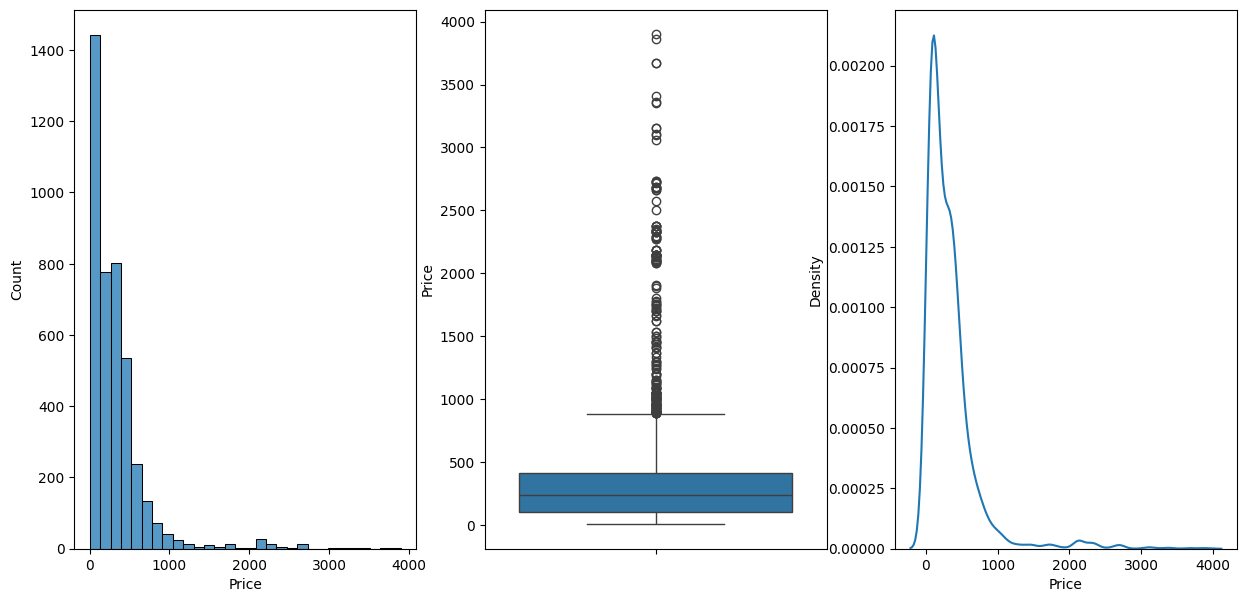

In [51]:
plt.figure(figsize=(15,7))

plt.subplot(1,3,1)
sns.histplot(df['Price'], bins=30)

plt.subplot(1,3,2)
sns.boxplot(df['Price'])

plt.subplot(1,3,3)
sns.kdeplot(df['Price'])

## Missing Value

In [4]:
missing = df.isnull().sum()
missing = missing[missing>0].sort_values(ascending=False)

missing_pct =(missing / len(df)*100).round(2)

missing_df = pd.DataFrame(
    {'Missing':missing,
     'Missing_PCT':missing_pct}
)



In [5]:
missing_df

,Missing,Missing_PCT
Hard Drive Capacity,3079,73.61
Ram Size,2531,60.51
Height of the Display,2268,54.22
Width of the Display,2268,54.22
Features,2190,52.35
Processor Speed,2093,50.04
SSD Capacity,2056,49.15
Screen Size (inch),1638,39.16


In [26]:
# import matplotlib.pyplot as plt

# plt.figure(figsize=(6,4))
# plt.scatter(x=df["Processor Speed"], y=df["Price"])
# plt.xlabel("Processor Speed")
# plt.ylabel("Price")
# plt.title("Processor Speed vs Price")
# plt.show()

* Drop 'Hard Drive Capacity'
* Drop the 'Ram Size'
* 


* SSD Capacity -> SimpleImputer
* Screen Size (inch) -> SimpleImputer

In [ ]:
print(df["Processor Speed Unit"].value_counts())

Processor Speed Unit
unknown    2093
GHz        2086
MHz           4
Name: count, dtype: int64


In [ ]:
df['Screen Size (inch)']=pd.to_numeric(df['Screen Size (inch)'],errors='coerce')
df['Processor Speed']=pd.to_numeric(df['Processor Speed'],errors='coerce')


<BarContainer object of 8 artists>

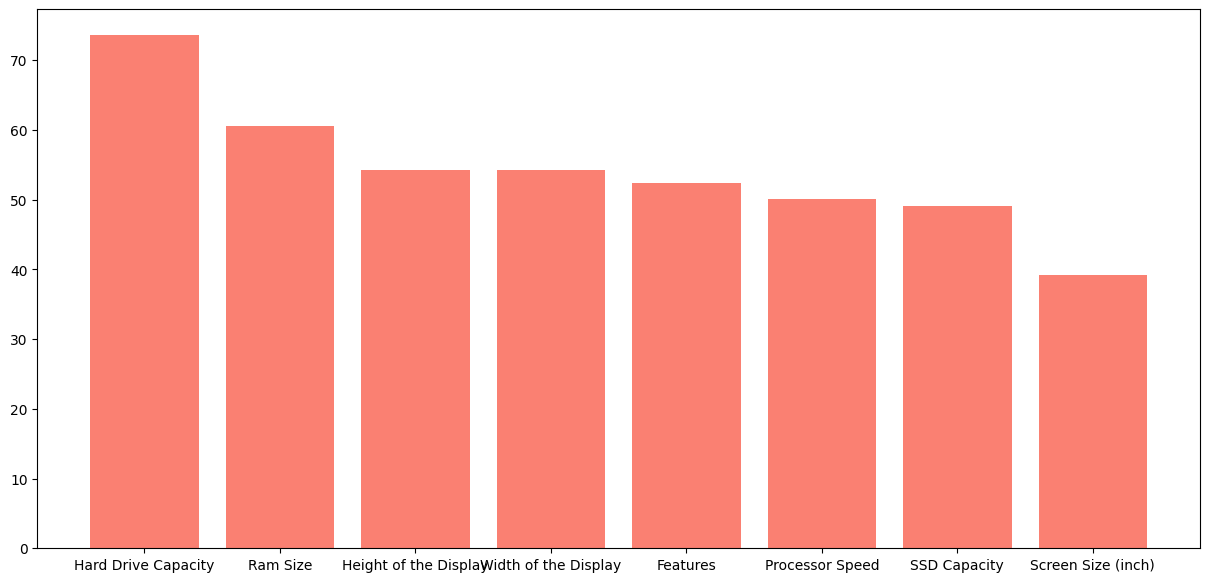

In [ ]:
plt.figure(figsize=(15,7))

plt.bar(missing_df.index,missing_df['Missing_PCT'],color='salmon')

<Axes: >

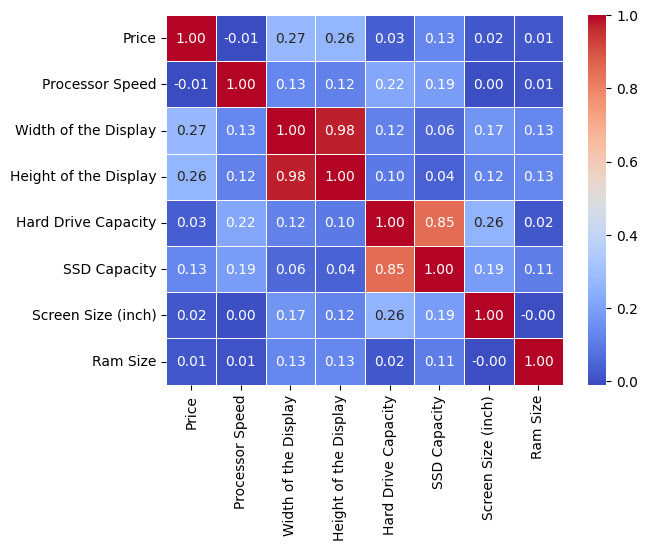

In [ ]:
correlation = df[num_cols].corr()
sns.heatmap(correlation, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)

##### Now in the correlation heatmap has present the multicolonarity present between the 'Width of the Display ' and the 'height of the display'
 * width of the Display has highest positive correlation with the target column , is 0.27
 * and after that has hoghst positive correlation of 'Height of the display ' is 0.26

## Numerical Column

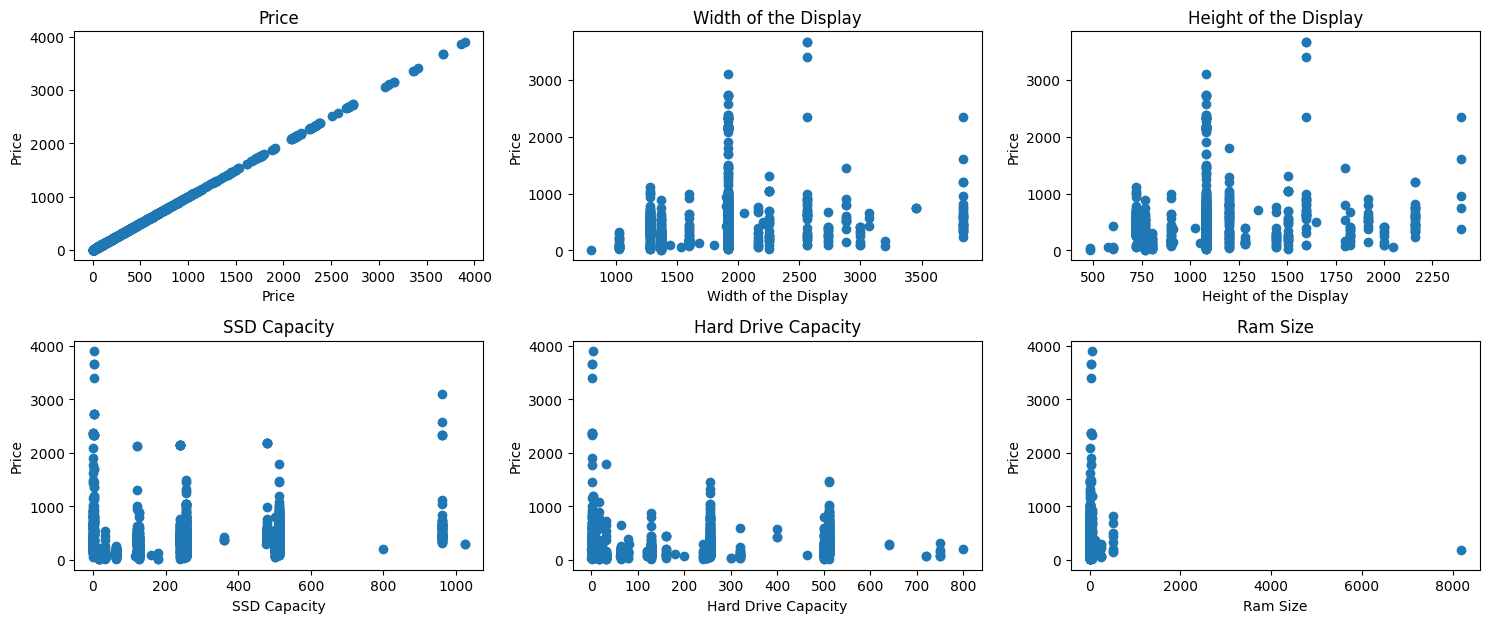

In [ ]:

corr = df.corr(numeric_only=True)
top_features = corr["Price"].abs().sort_values(ascending=False).index.tolist()

plt.figure(figsize=(15, 9))

for i, feature in enumerate(top_features, 1):
    plt.subplot(3, 3, i)
    plt.scatter(df[feature], df["Price"])
    plt.xlabel(feature)
    plt.ylabel("Price")
    plt.title(feature)

plt.tight_layout()
plt.show()

In [ ]:
# EDA on Each and Every Column

In [55]:
df.columns

Index(['Brand', 'Price', 'Currency', 'Color', 'Features', 'Condition',
       'Condition Description', 'Seller Note', 'GPU', 'Processor',
       'Processor Speed', 'Processor Speed Unit', 'Type',
       'Width of the Display', 'Height of the Display', 'OS', 'Storage Type',
       'Hard Drive Capacity', 'Hard Drive Capacity Unit', 'SSD Capacity',
       'SSD Capacity Unit', 'Screen Size (inch)', 'Ram Size', 'Ram Size Unit'],
      dtype='object')

In [ ]:
df.shape

(4183, 24)

In [ ]:
df['Brand']

0        other
1         dell
2         dell
3           hp
4         dell
         ...  
4178     other
4179      acer
4180      dell
4181        hp
4182    lenovo
Name: Brand, Length: 4183, dtype: object

In [17]:
df['Brand'].isnull().sum()

np.int64(0)

<Axes: xlabel='Brand'>

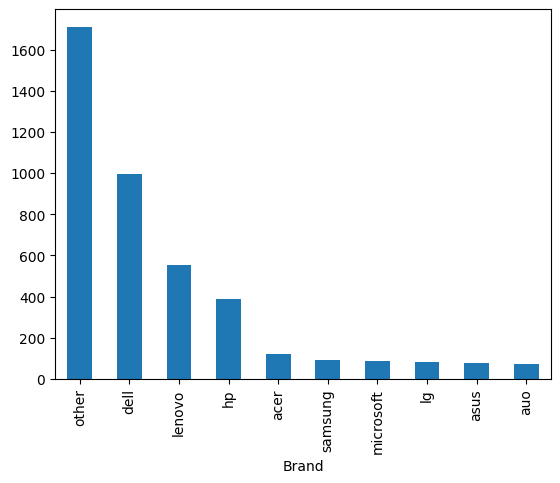

In [19]:
df['Brand'].value_counts().plot(kind='bar')

### Currency

### Color

### Features

In [56]:
df['Features'].isnull().sum()

np.int64(2190)

In [73]:
df['Features']

0       Backlit Keyboard,Built-in Microphone,Built-in ...
1       Backlit Keyboard,Bluetooth,Built-in Microphone...
2       10/100 LAN Card,Backlit Keyboard,Bluetooth,Bui...
3       Bluetooth,Built-in Microphone,Built-in Webcam,...
4       10/100 LAN Card,Built-in Microphone,Built-in W...
                              ...                        
4178                                                  NaN
4179                                                  NaN
4180    Touchscreen,10/100 LAN Card,Bluetooth,Backlit ...
4181                                                  NaN
4182                                                  NaN
Name: Features, Length: 4183, dtype: object

In [69]:
df["Features"] = df["Features"].str.replace(", ", ",")

In [70]:
feature_df = df["Features"].str.get_dummies(sep=",")

In [71]:
feature_df.shape

(4183, 306)

In [74]:
df["Features"] = df["Features"].str.replace(r"\s*,\s*", ",", regex=True)

In [77]:
feature_counts = df["Features"].str.get_dummies(sep=",").sum()
print(feature_counts.sort_values(ascending=False).head(30))

Wi-Fi                               1467
Bluetooth                           1323
Built-in Webcam                     1303
Built-in Microphone                  820
10/100 LAN Card                      674
Backlit Keyboard                     557
Touchscreen                          521
Multi-Touch Trackpad                 175
SD Card Reader                       171
Widescreen Display                   163
Touch ID                             147
Optical Drive                        125
Convertible 2-in-1 Laptop/Tablet     105
Rugged                                96
LTE                                   76
Stylus                                40
Force Touch Trackpad                  38
Shockproof                            32
Player SD                             26
Fingerprint Reader                    21
3D Camera                             18
Double battery                        17
Webcam                                15
SIM slots                             14
5G              

In [76]:
df["Features"] = df["Features"].str.replace("Webcam integrated", "Built-in Webcam")
df["Features"] = df["Features"].str.replace("Wireless LAN", "Wi-Fi")

In [78]:
feature_df = feature_df.loc[:, feature_df.sum() >= 50]

print(feature_df.shape)

(4183, 16)


In [81]:
df.shape

(4183, 24)

### Condition

In [83]:
df['Condition'].nunique()

10

In [84]:
df["Condition"] = df["Condition"].str.replace(r"\s*,\s*", ",", regex=True)

In [88]:
condition_counts = df["Condition"].str.get_dummies(sep=",").sum()
print(condition_counts.sort_values(ascending=False).head(30))

Used                        2028
New                          840
Undefined                    451
Seller refurbished           337
For parts or not working     121
Very Good - Refurbished      119
Good - Refurbished           102
Excellent - Refurbished       81
Open box                      76
Certified - Refurbished       28
dtype: int64


In [28]:
df['Condition Description']

0       A brand-new, unused, unopened, undamaged item ...
1       The item shows minimal wear and is backed by a...
2       An item that has been used previously. The ite...
3       The item shows moderate wear and is backed by ...
4       The item shows moderate wear and is backed by ...
                              ...                        
4178    A brand-new, unused, unopened, undamaged item ...
4179    A brand-new, unused, unopened, undamaged item ...
4180    An item that has been used previously. The ite...
4181    A brand-new, unused, unopened, undamaged item ...
4182                                            Undefined
Name: Condition Description, Length: 4183, dtype: object

In [ ]:
df['Seller Note'].value_counts()
# Its also have many unique content , so also dont want to use this for model training

Seller Note
undefined                                                                                                                                                                                                                                                                                                                                                                                                               3071
see description for item grade                                                                                                                                                                                                                                                                                                                                                                                            21
these units are fully functional and have all necessary accessories including a new operating system.                                                             

## GPU

<Axes: xlabel='GPU'>

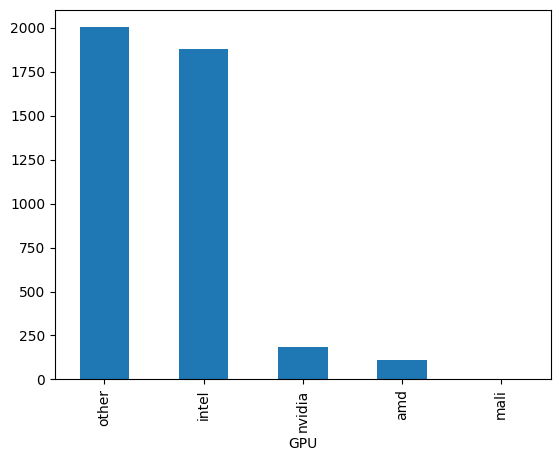

In [33]:
df['GPU'].value_counts().plot(kind='bar')

<Axes: xlabel='GPU', ylabel='Price'>

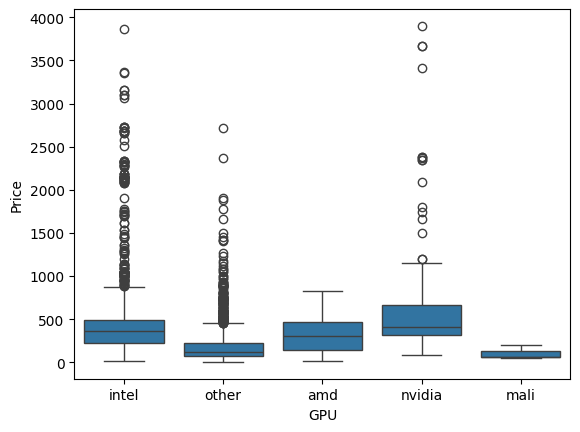

In [37]:
sns.boxplot(x=df['GPU'],y=df['Price'],data=df)

### Processor

In [38]:
df['Processor']

0                          quad core
1       intel core i7 8th generation
2                intel core i5-6300u
3                    intel celeron n
4       intel core i5 6th generation
                    ...             
4178                       undefined
4179                  not applicable
4180    intel core i5 6th generation
4181                  not applicable
4182                       undefined
Name: Processor, Length: 4183, dtype: object

In [40]:
df['Processor Speed'].isnull().sum()

np.int64(2093)

<Axes: xlabel='Processor Speed'>

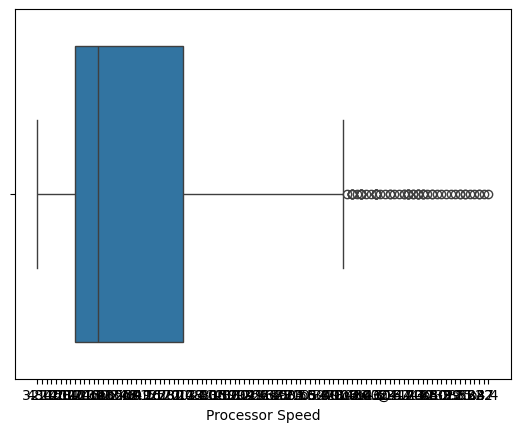

In [44]:
sns.boxplot(x=df['Processor Speed'])

In [64]:

df['Processor Speed']=pd.to_numeric(df['Processor Speed'],errors='coerce')

In [ ]:
# df[df['Processor Speed Unit']=='MHz']
mask = df["Processor Speed Unit"] == "MHz"

df.loc[mask, "Processor Speed"] = (
    df.loc[mask, "Processor Speed"] / 1000
)

# After conversion, drop the unit column
df.drop(columns=["Processor Speed Unit"], inplace=True)

### Type

In [72]:
df['Type'].value_counts()

Type
notebook/laptop    2215
other              1968
Name: count, dtype: int64

In [73]:
df.columns

Index(['Brand', 'Price', 'Currency', 'Color', 'Features', 'Condition',
       'Condition Description', 'Seller Note', 'GPU', 'Processor',
       'Processor Speed', 'Type', 'Width of the Display',
       'Height of the Display', 'OS', 'Storage Type', 'Hard Drive Capacity',
       'Hard Drive Capacity Unit', 'SSD Capacity', 'SSD Capacity Unit',
       'Screen Size (inch)', 'Ram Size', 'Ram Size Unit'],
      dtype='object')

In [75]:
df['Height of the Display']

0       1440.0
1       1080.0
2       1080.0
3        768.0
4        768.0
         ...  
4178       NaN
4179       NaN
4180    1080.0
4181       NaN
4182       NaN
Name: Height of the Display, Length: 4183, dtype: float64

In [77]:
df['OS'].value_counts()

OS
windows    1968
unknown    1920
chrome      259
linux        21
mac           8
android       7
Name: count, dtype: int64

In [88]:
df['Storage Type'].value_counts()

Storage Type
unknown    1763
ssd        1476
SSD         496
hdd/ssd     202
emmc        158
other        49
HDD          39
Name: count, dtype: int64

In [92]:
df.loc[
    (df["Storage Type"] == "unknown" ) &
    (df["SSD Capacity"] > 0),
    "Storage Type"
] = "ssd"

df.loc[
    (df["Storage Type"] == "unknown" ) &
    (df["Hard Drive Capacity"] > 0),
    "Storage Type"
] = "hdd"

In [97]:
df['Storage Type'].value_counts()

Storage Type
ssd        1972
unknown    1763
hdd/ssd     241
emmc        158
other        49
Name: count, dtype: int64

In [96]:
df['Storage Type']=df['Storage Type'].str.replace('SSD','ssd')
df['Storage Type']=df['Storage Type'].str.replace('HDD','hdd/ssd')